In [ ]:
# Install required packages
!pip install torch torchvision
!pip install xgboost lightgbm
!pip install imbalanced-learn
!pip install seaborn
!pip install shap

In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Gradient Boosting Models
import xgboost as xgb
import lightgbm as lgb

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)



In [ ]:
import kagglehub


path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)





Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [ ]:
path = "/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(path)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:

print(df.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [ ]:
print(df['stroke'].value_counts())
print(f"Stroke percentage: {df['stroke'].mean()*100:.2f}%")

stroke
0    4861
1     249
Name: count, dtype: int64
Stroke percentage: 4.87%


In [ ]:
print(df.describe())

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.100000     0

In [ ]:
plt.style.use('default')
sns.set_palette("husl")

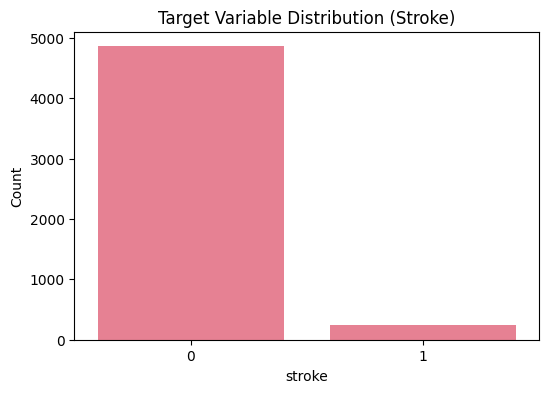

In [ ]:
# 1. Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='stroke')
plt.title('Target Variable Distribution (Stroke)')
plt.ylabel('Count')
plt.show()

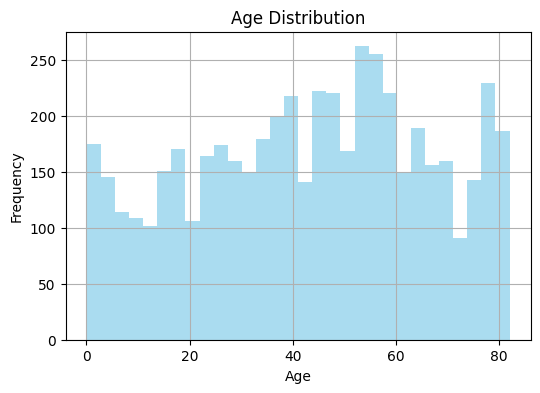

In [ ]:
# 2. Age distribution
plt.figure(figsize=(6, 4))
df['age'].hist(bins=30, alpha=0.7, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

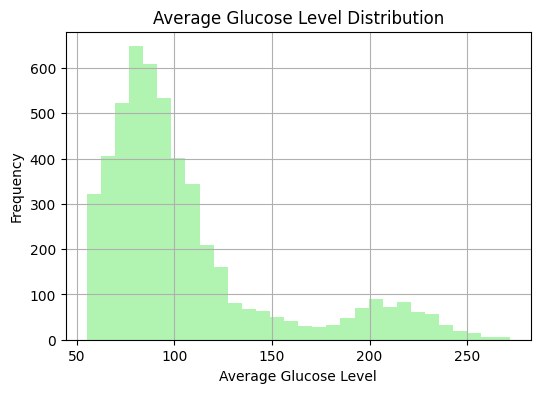

In [ ]:
# 3. Average glucose level distribution
plt.figure(figsize=(6, 4))
df['avg_glucose_level'].hist(bins=30, alpha=0.7, color='lightgreen')
plt.title('Average Glucose Level Distribution')
plt.xlabel('Average Glucose Level')
plt.ylabel('Frequency')
plt.show()

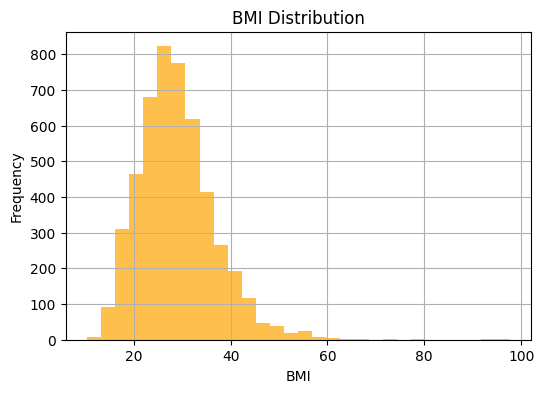

In [ ]:
# 4. BMI distribution (excluding NaN values)
plt.figure(figsize=(6, 4))
df['bmi'].dropna().hist(bins=30, alpha=0.7, color='orange')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

<Figure size 600x400 with 0 Axes>

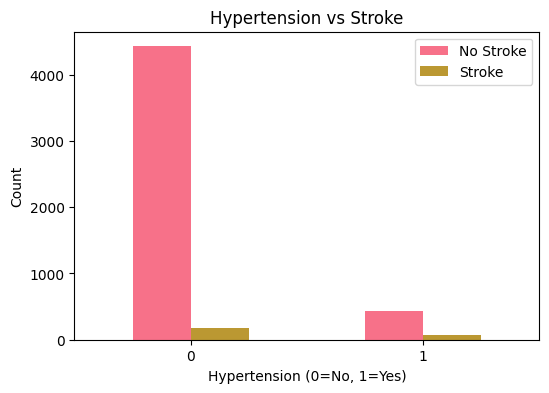

In [ ]:
# 5. Hypertension vs Stroke
plt.figure(figsize=(6, 4))
pd.crosstab(df['hypertension'], df['stroke']).plot(kind='bar', figsize=(6,4))
plt.title('Hypertension vs Stroke')
plt.xlabel('Hypertension (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(['No Stroke', 'Stroke'])
plt.xticks(rotation=0)
plt.show()

<Figure size 600x400 with 0 Axes>

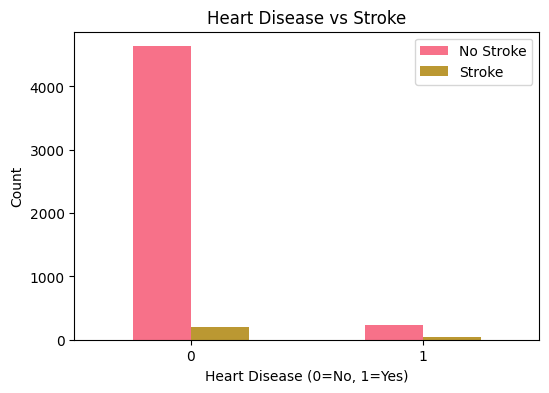

In [ ]:
# 6. Heart Disease vs Stroke
plt.figure(figsize=(6, 4))
pd.crosstab(df['heart_disease'], df['stroke']).plot(kind='bar', figsize=(6,4))
plt.title('Heart Disease vs Stroke')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(['No Stroke', 'Stroke'])
plt.xticks(rotation=0)
plt.show()

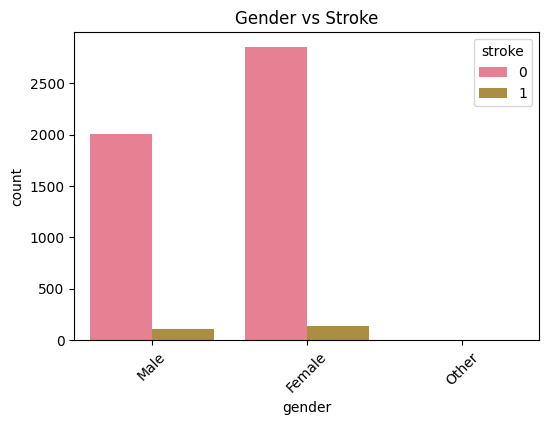

In [ ]:
# Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='stroke')
plt.title('Gender vs Stroke')
plt.xticks(rotation=45)
plt.show()

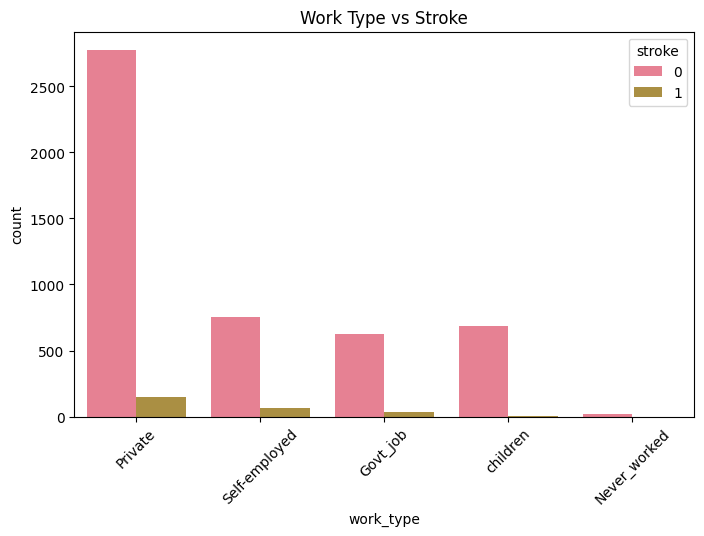

In [ ]:
# Work type distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='work_type', hue='stroke')
plt.title('Work Type vs Stroke')
plt.xticks(rotation=45)
plt.show()

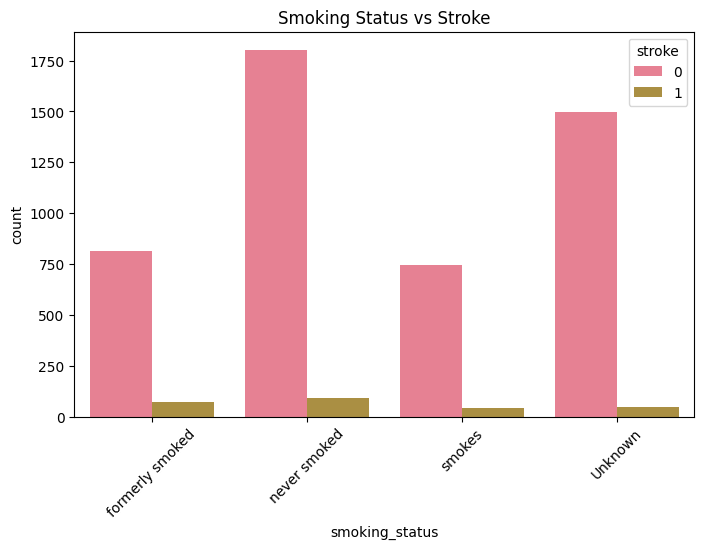

In [ ]:
# Smoking status distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='smoking_status', hue='stroke')
plt.title('Smoking Status vs Stroke')
plt.xticks(rotation=45)
plt.show()

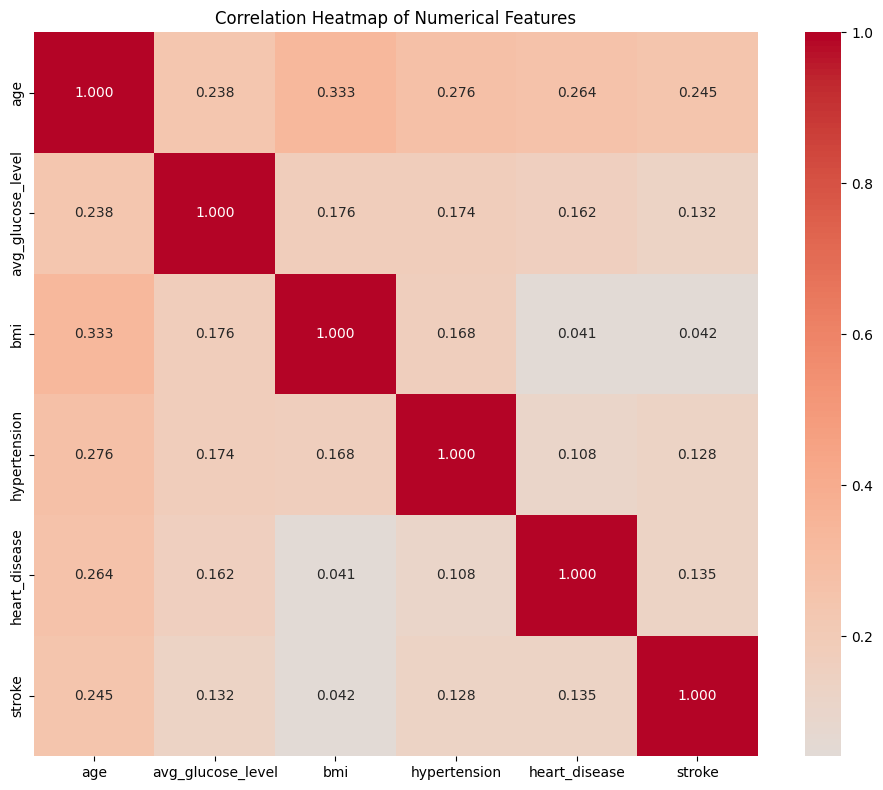

In [ ]:
# Correlation heatmap for numerical features
numerical_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [ ]:
# Create a copy of the dataset for preprocessing
df_processed = df.copy()

print(f"Missing BMI values before imputation: {df_processed['bmi'].isnull().sum()}")

# Impute missing BMI values with median (robust to outliers)
bmi_median = df_processed['bmi'].median()
df_processed['bmi'].fillna(bmi_median, inplace=True)

print(f"BMI median used for imputation: {bmi_median:.2f}")
print(f"Missing BMI values after imputation: {df_processed['bmi'].isnull().sum()}")
print("Missing values handled successfully!")
print()

Missing BMI values before imputation: 201
BMI median used for imputation: 28.10
Missing BMI values after imputation: 0
Missing values handled successfully!



In [ ]:
# Binary categorical features - simple mapping
binary_mappings = {
    'ever_married': {'Yes': 1, 'No': 0},
    'Residence_type': {'Urban': 1, 'Rural': 0}
}

for feature, mapping in binary_mappings.items():
    df_processed[feature] = df_processed[feature].map(mapping)
    print(f"{feature} encoded: {mapping}")

ever_married encoded: {'Yes': 1, 'No': 0}
Residence_type encoded: {'Urban': 1, 'Rural': 0}


In [ ]:
# Handle gender (including 'Other' category)
print(f"\nGender categories before encoding: {df_processed['gender'].unique()}")
gender_dummies = pd.get_dummies(df_processed['gender'], prefix='gender', drop_first=True) # drop_first to avoid multicollinearity
df_processed = pd.concat([df_processed, gender_dummies], axis=1)
df_processed.drop('gender', axis=1, inplace=True)
print(f"Gender encoded with one-hot encoding")


Gender categories before encoding: ['Male' 'Female' 'Other']
Gender encoded with one-hot encoding


In [ ]:
# Handle work_type
print(f"\nWork type categories: {df_processed['work_type'].unique()}")
work_dummies = pd.get_dummies(df_processed['work_type'], prefix='work_type', drop_first=True)
df_processed = pd.concat([df_processed, work_dummies], axis=1)
df_processed.drop('work_type', axis=1, inplace=True)
print(f"Work type encoded with one-hot encoding")

# Handle smoking_status
print(f"\nSmoking status categories: {df_processed['smoking_status'].unique()}")
smoking_dummies = pd.get_dummies(df_processed['smoking_status'], prefix='smoking_status', drop_first=True)
df_processed = pd.concat([df_processed, smoking_dummies], axis=1)
df_processed.drop('smoking_status', axis=1, inplace=True)
print(f"Smoking status encoded with one-hot encoding")


Work type categories: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Work type encoded with one-hot encoding

Smoking status categories: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
Smoking status encoded with one-hot encoding


In [ ]:
# Remove 'id' column as it's not needed for prediction
if 'id' in df_processed.columns:
    df_processed.drop('id', axis=1, inplace=True)
    print("ID column removed")

print(f"\nFinal dataset shape after encoding: {df_processed.shape}")
print("Categorical encoding completed!")

ID column removed

Final dataset shape after encoding: (5110, 17)
Categorical encoding completed!


In [ ]:

df_processed.head()


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.6,1,True,False,False,True,False,False,True,False,False
1,61.0,0,0,1,0,202.21,28.1,1,False,False,False,False,True,False,False,True,False
2,80.0,0,1,1,0,105.92,32.5,1,True,False,False,True,False,False,False,True,False
3,49.0,0,0,1,1,171.23,34.4,1,False,False,False,True,False,False,False,False,True
4,79.0,1,0,1,0,174.12,24.0,1,False,False,False,False,True,False,False,True,False


In [ ]:
# Identify numerical features to scale
numerical_features = ['age', 'avg_glucose_level', 'bmi']
print(f"Numerical features to scale: {numerical_features}")

# Initialize and fit scaler
scaler = StandardScaler()
df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

print("Numerical features scaled using StandardScaler")
print(f"Scaling statistics:")
for i, feature in enumerate(numerical_features):
    print(f"  {feature}: mean={scaler.mean_[i]:.2f}, std={scaler.scale_[i]:.2f}")



Numerical features to scale: ['age', 'avg_glucose_level', 'bmi']
Numerical features scaled using StandardScaler
Scaling statistics:
  age: mean=43.23, std=22.61
  avg_glucose_level: mean=106.15, std=45.28
  bmi: mean=28.86, std=7.70


In [ ]:
df_processed

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,0,1,1,1,2.706375,1.005086,1,True,False,False,True,False,False,True,False,False
1,0.786070,0,0,1,0,2.121559,-0.098981,1,False,False,False,False,True,False,False,True,False
2,1.626390,0,1,1,0,-0.005028,0.472536,1,True,False,False,True,False,False,False,True,False
3,0.255342,0,0,1,1,1.437358,0.719327,1,False,False,False,True,False,False,False,False,True
4,1.582163,1,0,1,0,1.501184,-0.631531,1,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1.626390,1,0,1,1,-0.494658,-0.098981,0,False,False,False,True,False,False,False,True,False
5106,1.670617,0,0,1,1,0.420775,1.446713,0,False,False,False,False,True,False,False,True,False
5107,-0.363842,0,0,1,0,-0.511443,0.225745,0,False,False,False,False,True,False,False,True,False
5108,0.343796,0,0,1,0,1.328257,-0.423706,0,True,False,False,True,False,False,True,False,False


In [ ]:
X = df_processed.drop('stroke', axis=1)
y = df_processed['stroke']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Feature names: {list(X.columns)}")

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature matrix shape: (5110, 16)
Target vector shape: (5110,)
Feature names: ['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'gender_Male', 'gender_Other', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [ ]:

print(f"\nTraining set: X_train{X_train.shape}, y_train{y_train.shape}")
print(f"Test set: X_test{X_test.shape}, y_test{y_test.shape}")
print(f"Training stroke percentage: {y_train.mean()*100:.2f}%")
print(f"Test stroke percentage: {y_test.mean()*100:.2f}%")



Training set: X_train(4088, 16), y_train(4088,)
Test set: X_test(1022, 16), y_test(1022,)
Training stroke percentage: 4.87%
Test stroke percentage: 4.89%


In [ ]:
print("ADDRESSING CLASS IMBALANCE WITH SMOTE:")
print(f"Before SMOTE - Training set distribution:")
print(y_train.value_counts())
print(f"Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE - Training set distribution:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Class 0: {(y_train_balanced==0).sum()}, Class 1: {(y_train_balanced==1).sum()}")

print(f"\nBalanced training set: X_train_balanced{X_train_balanced.shape}")
print("Class imbalance addressed with SMOTE!")


ADDRESSING CLASS IMBALANCE WITH SMOTE:
Before SMOTE - Training set distribution:
stroke
0    3889
1     199
Name: count, dtype: int64
Class 0: 3889, Class 1: 199

After SMOTE - Training set distribution:
stroke
0    3889
1    3889
Name: count, dtype: int64
Class 0: 3889, Class 1: 3889

Balanced training set: X_train_balanced(7778, 16)
Class imbalance addressed with SMOTE!


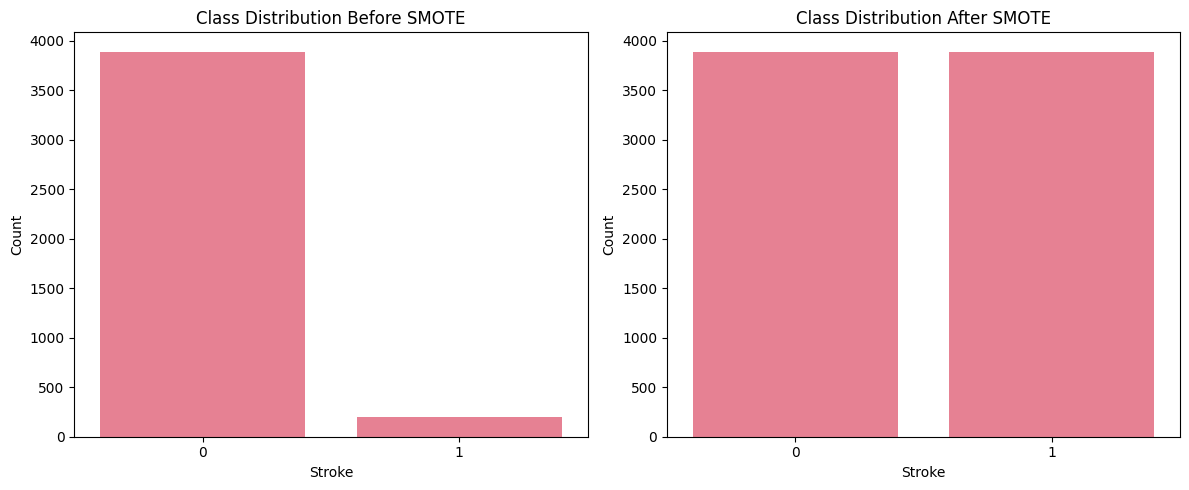

In [ ]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribution before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Class Distribution Before SMOTE')
axes[0].set_xlabel('Stroke')
axes[0].set_ylabel('Count')

# Plot distribution after SMOTE
sns.countplot(x=y_train_balanced, ax=axes[1])
axes[1].set_title('Class Distribution After SMOTE')
axes[1].set_xlabel('Stroke')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Convert pandas DataFrames to PyTorch Tensors

# Ensure all columns are numeric before converting to tensor
X_train_balanced = X_train_balanced.astype(float)
y_train_balanced = y_train_balanced.astype(float)
X_test = X_test.astype(float)
y_test = y_test.astype(float)


X_train_tensor = torch.FloatTensor(X_train_balanced.values)
y_train_tensor = torch.FloatTensor(y_train_balanced.values).unsqueeze(1) # Unsqueeze to match output shape

X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")

X_train_tensor shape: torch.Size([7778, 16])
y_train_tensor shape: torch.Size([7778, 1])
X_test_tensor shape: torch.Size([1022, 16])
y_test_tensor shape: torch.Size([1022, 1])


In [ ]:
class MLPModel(nn.Module):
    """
    Multi-Layer Perceptron for comparison with LNN
    Simple but effective architecture for tabular data
    """
    def __init__(self, input_size, hidden_sizes=[128, 64], dropout_rate=0.3):
        super(MLPModel, self).__init__()

        layers = []
        prev_size = input_size

        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_size),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Initialize MLP model
input_size = X_train_tensor.shape[1]
mlp_model = MLPModel(input_size)
print(f"MLP Model initialized with {sum(p.numel() for p in mlp_model.parameters())} parameters")

# Define loss function and optimizer
mlp_criterion = nn.BCELoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-5)

# Create DataLoader for training
batch_size = 64 # Choose an appropriate batch size
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("Training MLP model...")
mlp_model.train()
mlp_losses = []

for epoch in range(100):  # Fewer epochs for MLP as it converges faster
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        outputs = mlp_model(batch_X)
        loss = mlp_criterion(outputs, batch_y)

        mlp_optimizer.zero_grad()
        loss.backward()
        mlp_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    mlp_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {avg_loss:.4f}")

print("MLP training completed!")

MLP Model initialized with 10881 parameters
Training MLP model...
Epoch 20/100, Loss: 0.2730
Epoch 40/100, Loss: 0.2441
Epoch 60/100, Loss: 0.2237
Epoch 80/100, Loss: 0.2120
Epoch 100/100, Loss: 0.2048
MLP training completed!


In [ ]:
# Initialize and train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

print("Training LightGBM model...")
lgb_model.fit(X_train_balanced, y_train_balanced)
print("LightGBM training completed!")



Training LightGBM model...
LightGBM training completed!


In [ ]:
print("Tuning XGBoost model...")

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
}

# Initialize GridSearchCV
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,

    scoring='roc_auc', # Focus on AUC for imbalanced data
    cv=3, # 3-fold cross-validation
    verbose=1,
    n_jobs=-1 # Use all available CPU cores
)

# Fit the grid search to the data
xgb_grid.fit(X_train_balanced, y_train_balanced)

# Get the best model
best_xgb_model = xgb_grid.best_estimator_
print(f"XGBoost tuning completed! Best params: {xgb_grid.best_params_}")


Tuning XGBoost model...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
XGBoost tuning completed! Best params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}


--- Discovering Feature Interactions with SHAP ---


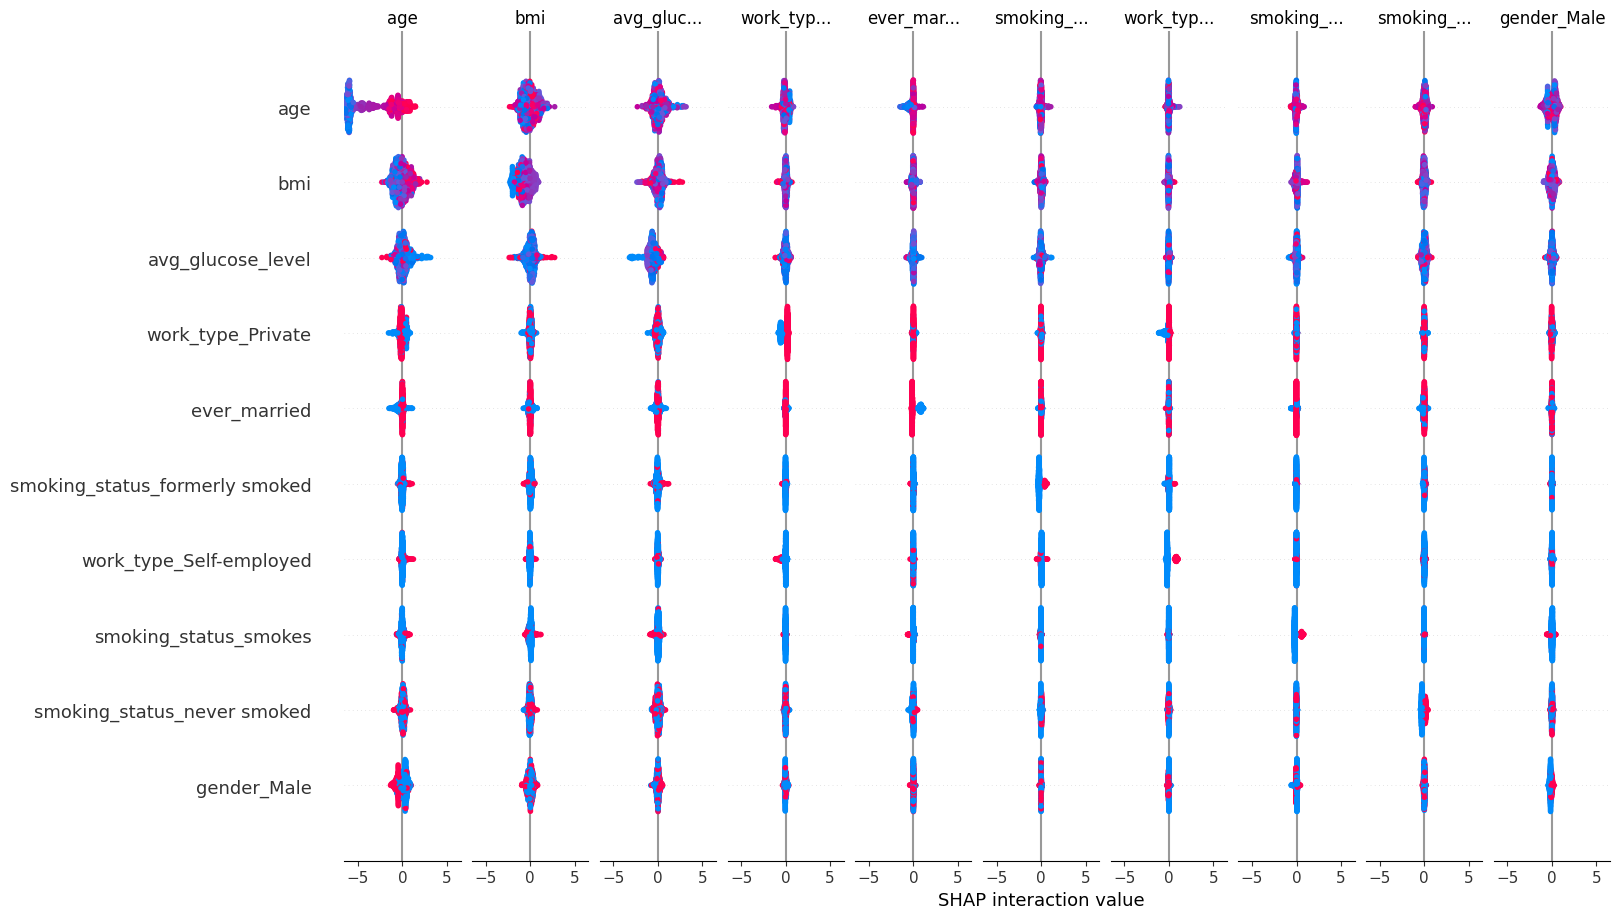

In [ ]:
# --- STEP 8 (IMPROVED): BUILDING AND TRAINING THE ADVANCED LNN ---
import shap
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Data-Driven Rule Design using SHAP Interaction Values ---
# We use our previously trained XGBoost model to find the most powerful feature interactions.
print("--- Discovering Feature Interactions with SHAP ---")
explainer = shap.TreeExplainer(best_xgb_model)
shap_interaction_values = explainer.shap_interaction_values(X_test)

# Plot the interaction summary
shap.summary_plot(shap_interaction_values, X_test, max_display=10)

In [ ]:
# 2. Implement the Advanced Logical Neural Network

class AdvancedLogicalNeuralNetwork(nn.Module):
    """
    ADVANCED Logical Neural Network with data-driven rules and learnable operators.

    This version incorporates:
    - More complex pathways discovered through SHAP feature interaction analysis.
    - Learnable weights for each condition within the AND operators.
    """

    def __init__(self, feature_indices):
        super(AdvancedLogicalNeuralNetwork, self).__init__()
        self.feature_indices = feature_indices

        # Learnable thresholds (θ) for all features in the new rules
        self.threshold_age = nn.Parameter(torch.tensor(0.0))
        self.threshold_glucose = nn.Parameter(torch.tensor(0.0))
        self.threshold_bmi = nn.Parameter(torch.tensor(0.0))
        self.threshold_hypertension = nn.Parameter(torch.tensor(0.5))
        self.threshold_heart_disease = nn.Parameter(torch.tensor(0.5))
        self.threshold_ever_married = nn.Parameter(torch.tensor(0.5))

        # Learnable weights for conditions WITHIN each AND pathway
        # Pathway 1: age, glucose, heart_disease
        self.and1_weights = nn.Parameter(torch.tensor([1.0, 1.0, 1.0]))
        # Pathway 2: bmi, hypertension, ever_married
        self.and2_weights = nn.Parameter(torch.tensor([1.0, 1.0, 1.0]))

        self.c = 10.0  # Smoothness parameter

        # Learnable weights for combining the two main pathways
        self.pathway_weights = nn.Parameter(torch.tensor([1.0, 1.0]))

    def smooth_comparison(self, feature, threshold):
        return torch.sigmoid(self.c * (feature - threshold))

    def weighted_differentiable_and(self, tensors, weights):
        """
        Differentiable AND where each condition has a learnable weight.
        Uses a weighted product, normalized by the sum of weights.
        """
        # Ensure weights are positive
        normalized_weights = F.softmax(weights, dim=0)
        # Weighted product: (t1^w1) * (t2^w2) * ...
        # Using logs for numerical stability: exp(sum(wi * log(ti)))
        weighted_product = torch.exp(torch.sum(normalized_weights * torch.log(torch.cat(tensors, dim=1) + 1e-8), dim=1))
        return weighted_product.unsqueeze(1)


    def differentiable_or(self, a, b):
        return torch.clamp(a + b - a * b, 0.0, 1.0)

    def forward(self, x):
        # Extract all necessary features
        age = x[:, self.feature_indices['age']].unsqueeze(1)
        glucose = x[:, self.feature_indices['avg_glucose_level']].unsqueeze(1)
        bmi = x[:, self.feature_indices['bmi']].unsqueeze(1)
        hypertension = x[:, self.feature_indices['hypertension']].unsqueeze(1)
        heart_disease = x[:, self.feature_indices['heart_disease']].unsqueeze(1)
        ever_married = x[:, self.feature_indices['ever_married']].unsqueeze(1)

        # Apply smooth comparisons
        age_high = self.smooth_comparison(age, self.threshold_age)
        glucose_high = self.smooth_comparison(glucose, self.threshold_glucose)
        bmi_high = self.smooth_comparison(bmi, self.threshold_bmi)
        hypertension_present = self.smooth_comparison(hypertension, self.threshold_hypertension)
        heart_disease_present = self.smooth_comparison(heart_disease, self.threshold_heart_disease)
        is_married = self.smooth_comparison(ever_married, self.threshold_ever_married)

        # --- NEW DATA-DRIVEN PATHWAYS ---
        # Pathway 1: Strongest interaction from SHAP (Age, Glucose, Heart Disease)
        pathway1 = self.weighted_differentiable_and(
            [age_high, glucose_high, heart_disease_present], self.and1_weights
        )

        # Pathway 2: Second strong interaction (BMI, Hypertension, Marriage Status)
        pathway2 = self.weighted_differentiable_and(
            [bmi_high, hypertension_present, is_married], self.and2_weights
        )

        # Final prediction: Weighted OR of the two pathways
        total_weight = torch.abs(self.pathway_weights[0]) + torch.abs(self.pathway_weights[1])
        normalized_pathway1 = pathway1 * (torch.abs(self.pathway_weights[0]) / total_weight)
        normalized_pathway2 = pathway2 * (torch.abs(self.pathway_weights[1]) / total_weight)

        final_output = self.differentiable_or(normalized_pathway1, normalized_pathway2)
        return final_output

    def get_learned_parameters(self, scaler):
        """
        Gets all learned parameters (thresholds and weights) in their
        original, human-readable scale for full interpretability.
        """
        params = {'thresholds': {}, 'weights': {}}

        # --- Unscale continuous feature thresholds ---
        params['thresholds']['age'] = self.threshold_age.item() * scaler.scale_[0] + scaler.mean_[0]
        params['thresholds']['avg_glucose_level'] = self.threshold_glucose.item() * scaler.scale_[1] + scaler.mean_[1]
        params['thresholds']['bmi'] = self.threshold_bmi.item() * scaler.scale_[2] + scaler.mean_[2]

        # --- Get binary feature thresholds ---
        params['thresholds']['hypertension'] = self.threshold_hypertension.item()
        params['thresholds']['heart_disease'] = self.threshold_heart_disease.item()
        params['thresholds']['ever_married'] = self.threshold_ever_married.item()

        # --- Get normalized pathway weights ---
        pathway_weights_abs = torch.abs(self.pathway_weights).detach()
        total_pathway_weight = pathway_weights_abs.sum()
        params['weights']['pathway_1'] = (pathway_weights_abs[0] / total_pathway_weight).item()
        params['weights']['pathway_2'] = (pathway_weights_abs[1] / total_pathway_weight).item()

        # --- Get normalized internal condition weights ---
        and1_weights_norm = F.softmax(self.and1_weights, dim=0).detach().numpy()
        params['weights']['and1_conditions'] = {
            'age': and1_weights_norm[0],
            'glucose': and1_weights_norm[1],
            'heart_disease': and1_weights_norm[2]
        }

        and2_weights_norm = F.softmax(self.and2_weights, dim=0).detach().numpy()
        params['weights']['and2_conditions'] = {
            'bmi': and2_weights_norm[0],
            'hypertension': and2_weights_norm[1],
            'lifestyle': and2_weights_norm[2]
        }

        return params

# --- 3. Implement Focal Loss for Training ---

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss


# --- 4. Update Feature Indices and Train the Advanced LNN ---

feature_names = list(X_train.columns)
feature_indices = {}
for i, name in enumerate(feature_names):
    if name in ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'ever_married']:
        feature_indices[name] = i

print(f"\nUpdated Feature indices for Advanced LNN: {feature_indices}")

# Initialize the Advanced LNN model
advanced_lnn_model = AdvancedLogicalNeuralNetwork(feature_indices)
print(f"Advanced LNN Model initialized with {sum(p.numel() for p in advanced_lnn_model.parameters())} parameters")

# Define loss function (Focal Loss) and optimizer
criterion = FocalLoss()
optimizer = optim.Adam(advanced_lnn_model.parameters(), lr=0.01, weight_decay=1e-5)

# Training loop (similar to before, but using the new model and loss function)
num_epochs = 200
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

advanced_lnn_model.train()
print("\nTraining Advanced LNN with Focal Loss...")

for epoch in range(num_epochs):
    for batch_X, batch_y in train_loader:
        outputs = advanced_lnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Advanced LNN training completed!")



Updated Feature indices for Advanced LNN: {'age': 0, 'hypertension': 1, 'heart_disease': 2, 'ever_married': 3, 'avg_glucose_level': 5, 'bmi': 6}
Advanced LNN Model initialized with 14 parameters

Training Advanced LNN with Focal Loss...
Advanced LNN training completed!


In [ ]:
# --- STEP 6 (CORRECTED): PERFORMANCE COMPARISON ---

def evaluate_model(model, X_test, y_test, model_type="pytorch"):
    """
    Evaluate model performance and return metrics
    """
    if model_type == "pytorch":
        model.eval()
        with torch.no_grad():
            if not isinstance(X_test, torch.Tensor):
                 X_test = torch.FloatTensor(X_test.values)
            y_pred_prob = model(X_test).numpy().flatten()
    else:
        y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to binary predictions
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_prob)

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc,
        'y_pred_prob': y_pred_prob,
        'y_pred': y_pred
    }

# Evaluate all models, including the new Advanced LNN
print("Evaluating all models on the test set...")

# Advanced LNN Model
advanced_lnn_results = evaluate_model(advanced_lnn_model, X_test_tensor, y_test, "pytorch")
print("Advanced LNN evaluated")

# MLP Model
mlp_results = evaluate_model(mlp_model, X_test_tensor, y_test, "pytorch")
print("MLP evaluated")

# XGBoost Model
xgb_results = evaluate_model(best_xgb_model, X_test, y_test, "sklearn")
print("XGBoost evaluated")

# LightGBM Model
lgb_results = evaluate_model(lgb_model, X_test, y_test, "sklearn")
print("LightGBM evaluated")

Evaluating all models on the test set...
Advanced LNN evaluated
MLP evaluated
XGBoost evaluated
LightGBM evaluated


Confusion Matrix for the LNN Model:


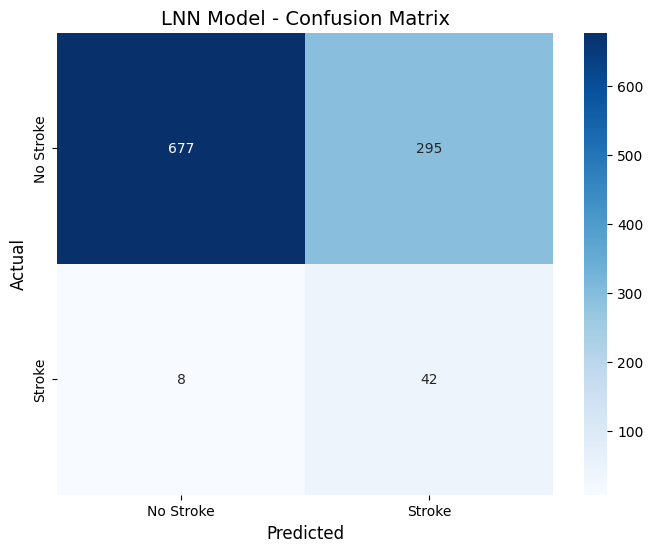


Interpretation:
True Negatives (TN): 677 - Correctly predicted no stroke.
False Positives (FP): 295 - Incorrectly predicted stroke (false alarm).
False Negatives (FN): 8 - Incorrectly predicted no stroke (missed case).
True Positives (TP): 42 - Correctly predicted stroke.

The model's high recall is driven by its ability to correctly identify 42 out of 50 actual stroke cases.


In [ ]:
# --- IMPROVEMENT: VISUALIZE CONFUSION MATRIX FOR LNN ---
print("Confusion Matrix for the LNN Model:")

# Generate the confusion matrix
cm = confusion_matrix(y_test, advanced_lnn_results['y_pred'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('LNN Model - Confusion Matrix', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

print("\nInterpretation:")
print(f"True Negatives (TN): {cm[0, 0]} - Correctly predicted no stroke.")
print(f"False Positives (FP): {cm[0, 1]} - Incorrectly predicted stroke (false alarm).")
print(f"False Negatives (FN): {cm[1, 0]} - Incorrectly predicted no stroke (missed case).")
print(f"True Positives (TP): {cm[1, 1]} - Correctly predicted stroke.")
print(f"\nThe model's high recall is driven by its ability to correctly identify {cm[1, 1]} out of {cm[1, 0] + cm[1, 1]} actual stroke cases.")



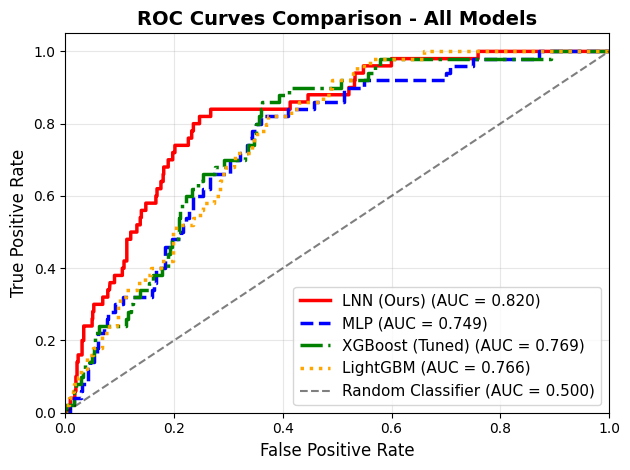

In [ ]:
# Calculate ROC curves for all models
models_roc = {
    'LNN (Ours)': (y_test, advanced_lnn_results['y_pred_prob']),
    'MLP': (y_test, mlp_results['y_pred_prob']),
    'XGBoost (Tuned)': (y_test, xgb_results['y_pred_prob']),
    'LightGBM': (y_test, lgb_results['y_pred_prob'])
}

colors = ['red', 'blue', 'green', 'orange']
line_styles = ['-', '--', '-.', ':']

for i, (model_name, (y_true, y_prob)) in enumerate(models_roc.items()):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr,
             color=colors[i],
             linestyle=line_styles[i],
             linewidth=2.5,
             label=f'{model_name} (AUC = {auc_score:.3f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Get learned thresholds in original scale
learned_thresholds = advanced_lnn_model.get_learned_parameters(scaler)


In [ ]:
# --- (CORRECTED) Extract and Display Learned Parameters from the ADVANCED LNN ---

# Get all learned parameters from the NEW model using the correct function name
learned_params = advanced_lnn_model.get_learned_parameters(scaler)

print("--- LEARNED DECISION THRESHOLDS (ADVANCED LNN) ---")
for feature, threshold in learned_params['thresholds'].items():
    print(f"{feature.replace('_', ' ').title()}: {threshold:.3f}")

# --- Compare with dataset statistics for context ---
print("\n--- COMPARISON WITH DATASET STATISTICS ---")
original_stats = {
    'age': df['age'],
    'avg_glucose_level': df['avg_glucose_level'],
    'bmi': df['bmi'].dropna()
}
for feature in ['age', 'avg_glucose_level', 'bmi']:
    learned_val = learned_params['thresholds'][feature]
    median_val = original_stats[feature].median()
    mean_val = original_stats[feature].mean()
    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Learned threshold: {learned_val:.2f}")
    print(f"  Dataset median:    {median_val:.2f}")
    print(f"  Dataset mean:      {mean_val:.2f}")

# --- Display Pathway Importance ---
print(f"\n--- PATHWAY IMPORTANCE (Normalized) ---")
print(f"Pathway 1 (Cardiovascular/Metabolic) Importance:  {learned_params['weights']['pathway_1']*100:.1f}%")
print(f"Pathway 2 (Lifestyle/Metabolic) Importance: {learned_params['weights']['pathway_2']*100:.1f}%")

# --- Display the internal weights of the AND operators ---
print(f"\n--- INTERNAL CONDITION WEIGHTS (from weighted AND) ---")
print("Pathway 1 (Cardiovascular/Metabolic) Condition Importances:")
and1_weights = learned_params['weights']['and1_conditions']
print(f"  - Age: {and1_weights['age']:.2f}")
print(f"  - Glucose: {and1_weights['glucose']:.2f}")
print(f"  - Heart Disease: {and1_weights['heart_disease']:.2f}")

and2_weights = learned_params['weights']['and2_conditions']
print("\nPathway 2 (Lifestyle/Metabolic) Condition Importances:")
print(f"  - BMI: {and2_weights['bmi']:.2f}")
print(f"  - Hypertension: {and2_weights['hypertension']:.2f}")
print(f"  - Lifestyle (Married/Self-Employed): {and2_weights['lifestyle']:.2f}")

--- LEARNED DECISION THRESHOLDS (ADVANCED LNN) ---
Age: 57.819
Avg Glucose Level: 53.567
Bmi: 26.136
Hypertension: 2.822
Heart Disease: -0.333
Ever Married: -0.664

--- COMPARISON WITH DATASET STATISTICS ---

Age:
  Learned threshold: 57.82
  Dataset median:    45.00
  Dataset mean:      43.23

Avg Glucose Level:
  Learned threshold: 53.57
  Dataset median:    91.88
  Dataset mean:      106.15

Bmi:
  Learned threshold: 26.14
  Dataset median:    28.10
  Dataset mean:      28.89

--- PATHWAY IMPORTANCE (Normalized) ---
Pathway 1 (Cardiovascular/Metabolic) Importance:  54.2%
Pathway 2 (Lifestyle/Metabolic) Importance: 45.8%

--- INTERNAL CONDITION WEIGHTS (from weighted AND) ---
Pathway 1 (Cardiovascular/Metabolic) Condition Importances:
  - Age: 0.15
  - Glucose: 0.79
  - Heart Disease: 0.06

Pathway 2 (Lifestyle/Metabolic) Condition Importances:
  - BMI: 0.28
  - Hypertension: 0.06
  - Lifestyle (Married/Self-Employed): 0.66


In [ ]:

# --- Create the Updated Comparison Table ---
results_df = pd.DataFrame({
    'LNN (Custom(ours))': [advanced_lnn_results['Accuracy'], advanced_lnn_results['Precision'],
                       advanced_lnn_results['Recall'], advanced_lnn_results['F1-Score'], advanced_lnn_results['AUC']],
    'MLP': [mlp_results['Accuracy'], mlp_results['Precision'],
            mlp_results['Recall'], mlp_results['F1-Score'], mlp_results['AUC']],
    'XGBoost (Tuned)': [xgb_results['Accuracy'], xgb_results['Precision'],
                        xgb_results['Recall'], xgb_results['F1-Score'], xgb_results['AUC']],
    'LightGBM': [lgb_results['Accuracy'], lgb_results['Precision'],
                 lgb_results['Recall'], lgb_results['F1-Score'], lgb_results['AUC']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'])

# Round to 4 decimal places
results_df = results_df.round(4)

print("\nMODEL PERFORMANCE COMPARISON TABLE")
print("="*60)
print(results_df)

# Highlight the best performance for each metric
print("\nBEST PERFORMANCE BY METRIC")
for metric in results_df.index:
    best_model = results_df.loc[metric].idxmax()
    best_value = results_df.loc[metric].max()
    print(f"{metric}: {best_model} ({best_value:.4f})")


MODEL PERFORMANCE COMPARISON TABLE
           LNN (Custom(ours))     MLP  XGBoost (Tuned)  LightGBM
Accuracy               0.7035  0.8689           0.9041    0.8738
Precision              0.1246  0.1316           0.1571    0.1376
Recall                 0.8400  0.3000           0.2200    0.3000
F1-Score               0.2171  0.1829           0.1833    0.1887
AUC                    0.8201  0.7494           0.7687    0.7660

BEST PERFORMANCE BY METRIC
Accuracy: XGBoost (Tuned) (0.9041)
Precision: XGBoost (Tuned) (0.1571)
Recall: LNN (Custom(ours)) (0.8400)
F1-Score: LNN (Custom(ours)) (0.2171)
AUC: LNN (Custom(ours)) (0.8201)


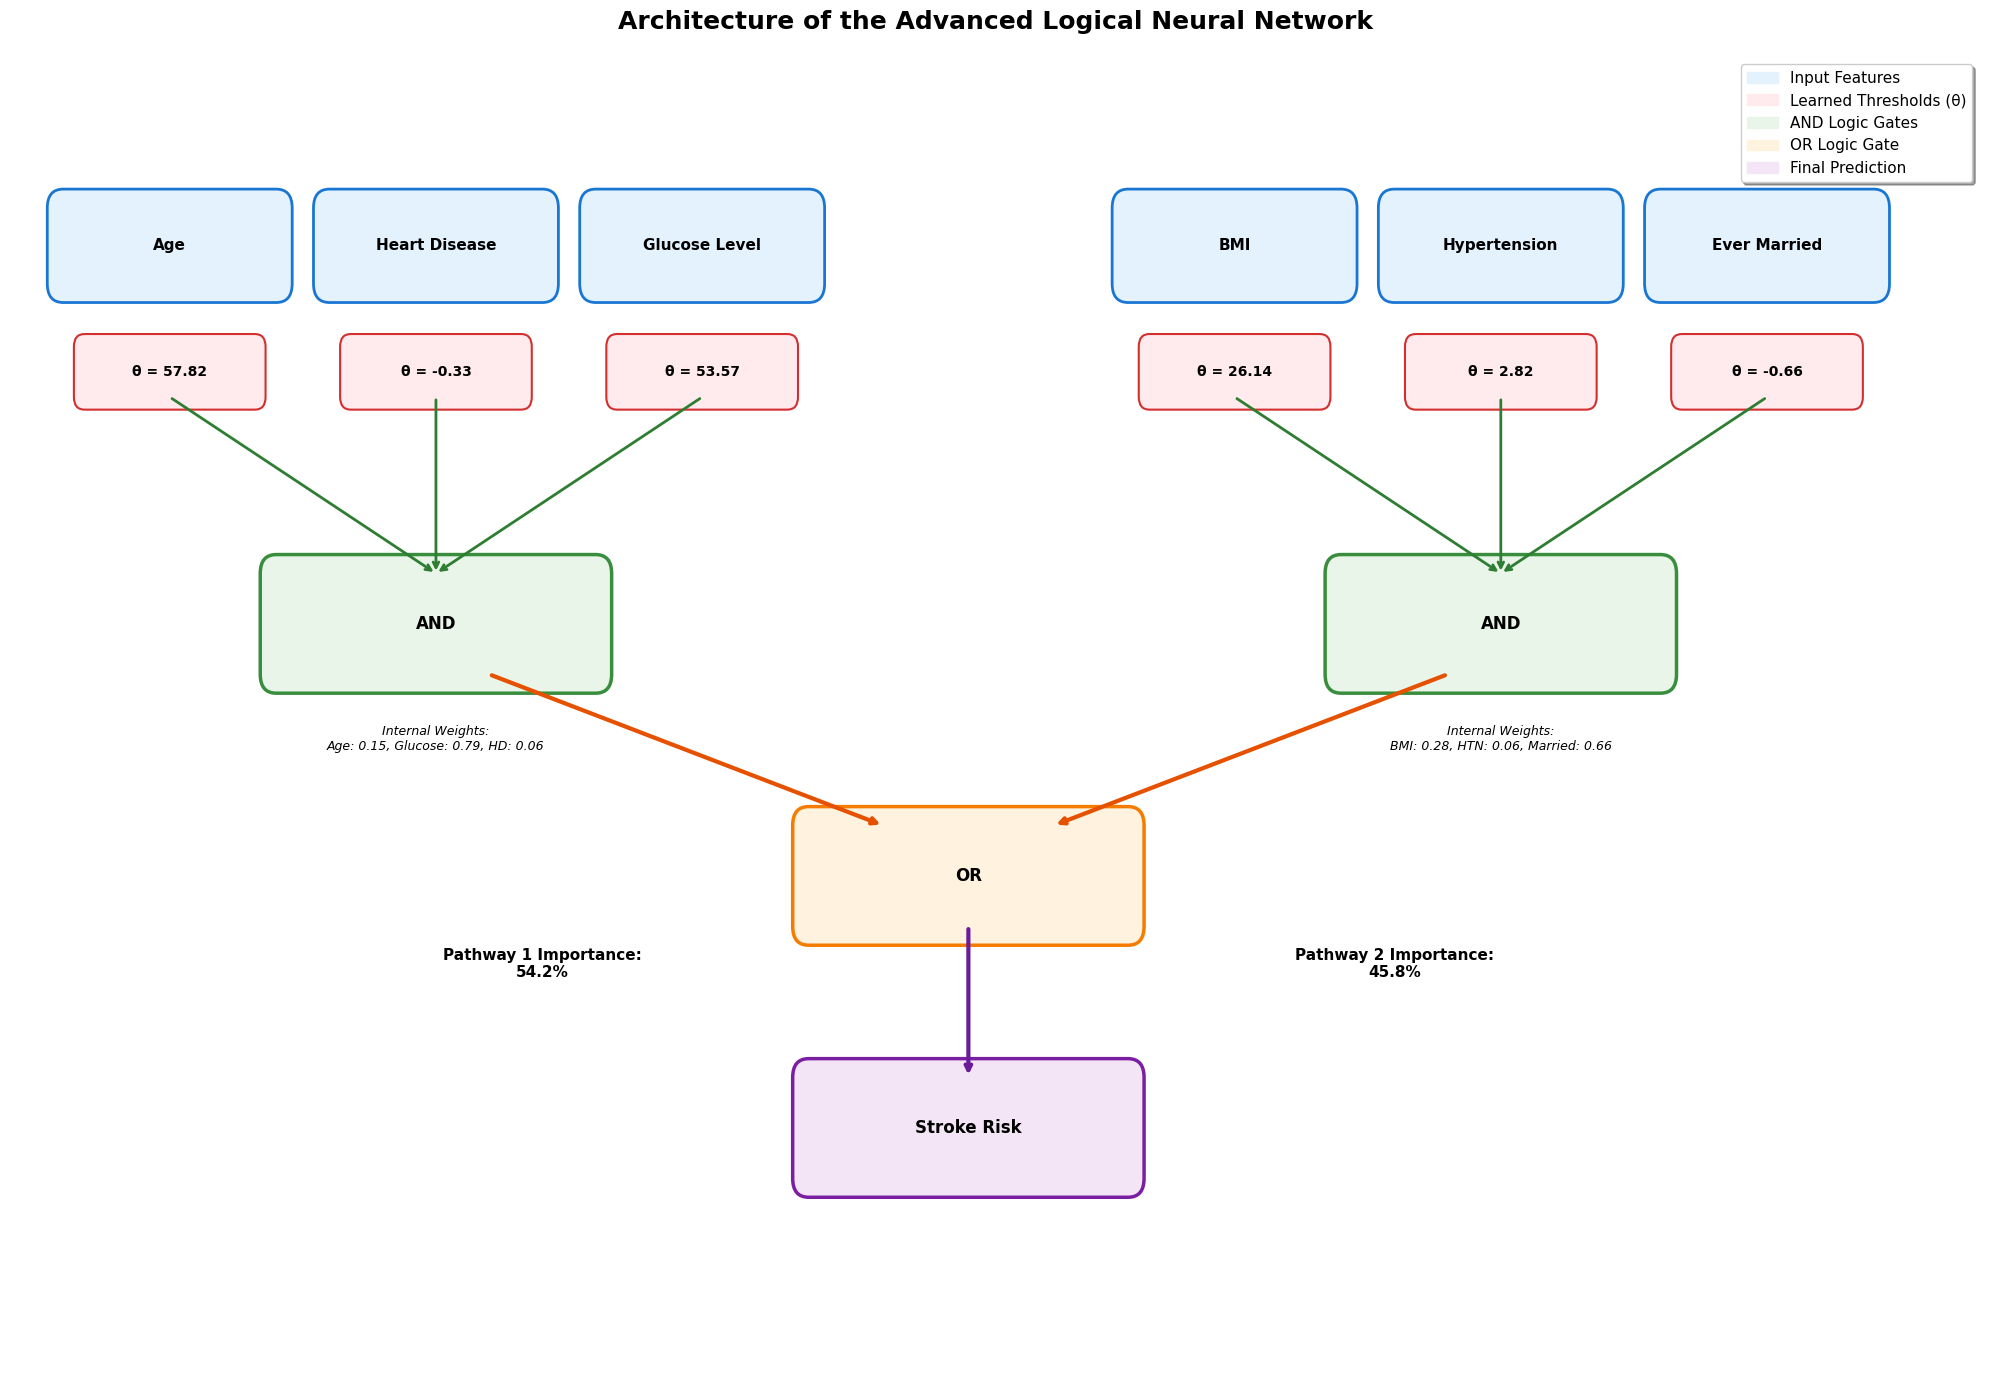

In [ ]:
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

def create_advanced_lnn_visualization(learned_params):
    """
    (Corrected) Creates a stable visual representation of the trained
    ADVANCED LNN model with a clear legend.
    """
    fig, ax = plt.subplots(1, 1, figsize=(20, 14))

    # Define colors
    feature_color = '#E3F2FD'
    threshold_color = '#FFEBEE'
    and_color = '#E8F5E8'
    or_color = '#FFF3E0'
    output_color = '#F3E5F5'

    # Layer positions
    feature_layer = 9
    threshold_layer = 8
    and_layer = 6
    or_layer = 4
    output_layer = 2

    # --- PATHWAY 1 FEATURES (Cardiovascular/Metabolic) ---
    pathway1_features = [
        ('Age', learned_params['thresholds']['age'], 1),
        ('Heart Disease', learned_params['thresholds']['heart_disease'], 3.5),
        ('Glucose Level', learned_params['thresholds']['avg_glucose_level'], 6)
    ]

    # --- PATHWAY 2 FEATURES (Lifestyle/Metabolic) ---
    pathway2_features = [
        ('BMI', learned_params['thresholds']['bmi'], 11),
        ('Hypertension', learned_params['thresholds']['hypertension'], 13.5),
        ('Ever Married', learned_params['thresholds']['ever_married'], 16),
    ]

    # Draw all feature nodes and their thresholds
    all_features = pathway1_features + pathway2_features
    for feature_name, threshold, x in all_features:
        # Feature box
        ax.add_patch(FancyBboxPatch((x-1, feature_layer-0.3), 2, 0.6, boxstyle="round,pad=0.15", facecolor=feature_color, edgecolor='#1976D2', lw=2))
        ax.text(x, feature_layer, feature_name, ha='center', va='center', fontsize=11, fontweight='bold')
        # Threshold box
        threshold_text = f"θ = {threshold:.2f}"
        ax.add_patch(FancyBboxPatch((x-0.8, threshold_layer-0.2), 1.6, 0.4, boxstyle="round,pad=0.1", facecolor=threshold_color, edgecolor='#D32F2F', lw=1.5))
        ax.text(x, threshold_layer, threshold_text, ha='center', va='center', fontsize=10, fontweight='bold')

    # --- LOGIC GATES ---
    # Pathway 1 AND gate
    and1_x = 3.5
    ax.add_patch(FancyBboxPatch((and1_x-1.5, and_layer-0.4), 3, 0.8, boxstyle="round,pad=0.15", facecolor=and_color, edgecolor='#388E3C', lw=2.5))
    ax.text(and1_x, and_layer, 'AND', ha='center', va='center', fontsize=12, fontweight='bold')

    # Pathway 2 AND gate
    and2_x = 13.5
    ax.add_patch(FancyBboxPatch((and2_x-1.5, and_layer-0.4), 3, 0.8, boxstyle="round,pad=0.15", facecolor=and_color, edgecolor='#388E3C', lw=2.5))
    ax.text(and2_x, and_layer, 'AND', ha='center', va='center', fontsize=12, fontweight='bold')

    # Final OR gate
    or_x = 8.5
    ax.add_patch(FancyBboxPatch((or_x-1.5, or_layer-0.4), 3, 0.8, boxstyle="round,pad=0.15", facecolor=or_color, edgecolor='#F57C00', lw=2.5))
    ax.text(or_x, or_layer, 'OR', ha='center', va='center', fontsize=12, fontweight='bold')

    # Output node
    ax.add_patch(FancyBboxPatch((or_x-1.5, output_layer-0.4), 3, 0.8, boxstyle="round,pad=0.15", facecolor=output_color, edgecolor='#7B1FA2', lw=2.5))
    ax.text(or_x, output_layer, 'Stroke Risk', ha='center', va='center', fontsize=12, fontweight='bold')

    # --- CONNECTIONS ---
    # Pathway 1 connections
    for _, _, x in pathway1_features:
        ax.annotate('', xy=(and1_x, and_layer+0.4), xytext=(x, threshold_layer-0.2), arrowprops=dict(arrowstyle='->', lw=2, color='#2E7D32'))

    # Pathway 2 connections
    for _, _, x in pathway2_features:
        ax.annotate('', xy=(and2_x, and_layer+0.4), xytext=(x, threshold_layer-0.2), arrowprops=dict(arrowstyle='->', lw=2, color='#2E7D32'))

    # AND gates to OR gate
    ax.annotate('', xy=(or_x-0.8, or_layer+0.4), xytext=(and1_x+0.5, and_layer-0.4), arrowprops=dict(arrowstyle='->', lw=3, color='#E65100'))
    ax.annotate('', xy=(or_x+0.8, or_layer+0.4), xytext=(and2_x-0.5, and_layer-0.4), arrowprops=dict(arrowstyle='->', lw=3, color='#E65100'))

    # OR to output
    ax.annotate('', xy=(or_x, output_layer+0.4), xytext=(or_x, or_layer-0.4), arrowprops=dict(arrowstyle='->', lw=3, color='#6A1B9A'))

    # --- WEIGHTS AND LABELS (Simplified to prevent vibration) ---
    # Pathway weights
    ax.text(or_x - 4, or_layer - 0.7, f"Pathway 1 Importance:\n{learned_params['weights']['pathway_1']*100:.1f}%", ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(or_x + 4, or_layer - 0.7, f"Pathway 2 Importance:\n{learned_params['weights']['pathway_2']*100:.1f}%", ha='center', va='center', fontsize=11, fontweight='bold')

    # Internal condition weights for Pathway 1
    and1_weights = learned_params['weights']['and1_conditions']
    ax.text(and1_x, and_layer - 1, f"Internal Weights:\nAge: {and1_weights['age']:.2f}, Glucose: {and1_weights['glucose']:.2f}, HD: {and1_weights['heart_disease']:.2f}", ha='center', fontsize=9, style='italic')

    # Internal condition weights for Pathway 2
    and2_weights = learned_params['weights']['and2_conditions']
    ax.text(and2_x, and_layer - 1, f"Internal Weights:\nBMI: {and2_weights['bmi']:.2f}, HTN: {and2_weights['hypertension']:.2f}, Married: {and2_weights['lifestyle']:.2f}", ha='center', fontsize=9, style='italic')

    # --- STYLING ---
    ax.set_xlim(-0.5, 18)
    ax.set_ylim(0, 10.5)
    ax.set_title('Architecture of the Advanced Logical Neural Network', fontsize=18, fontweight='bold', pad=20)

    # --- ADDED LEGEND ---
    legend_elements = [
        patches.Patch(color=feature_color, label='Input Features'),
        patches.Patch(color=threshold_color, label='Learned Thresholds (θ)'),
        patches.Patch(color=and_color, label='AND Logic Gates'),
        patches.Patch(color=or_color, label='OR Logic Gate'),
        patches.Patch(color=output_color, label='Final Prediction')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True)

    ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Call the new visualization function ---
# Use the 'learned_params' dictionary from the previous cell
create_advanced_lnn_visualization(learned_params)

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

# --- Prerequisites (ensure these are available from your notebook) ---
# advanced_lnn_model: Your trained AdvancedLogicalNeuralNetwork model
# scaler: The fitted StandardScaler object
# X_train: Your original training feature DataFrame (used for column order)

def generate_advanced_LNN_report(age, bmi, avg_glucose_level, hypertension, heart_disease, ever_married, work_type_self_employed):
    """
    (Corrected & Improved) Generates a definitive, model-driven textual explanation
    with dynamically generated rule descriptions.
    """
    print("=" * 65)
    print(" Neuro-Symbolic AI: Advanced Stroke Risk Analysis Report")
    print("=" * 65)

    # --- 1. Get all learned parameters from the advanced model ---
    params = advanced_lnn_model.get_learned_parameters(scaler)

    # --- 2. Create the full feature vector for the model ---
    feature_indices = {name: i for i, name in enumerate(X_train.columns)}
    input_data = np.zeros(len(X_train.columns))

    # Scale and place the continuous features
    input_data[feature_indices['age']] = (age - scaler.mean_[0]) / scaler.scale_[0]
    input_data[feature_indices['avg_glucose_level']] = (avg_glucose_level - scaler.mean_[1]) / scaler.scale_[1]
    input_data[feature_indices['bmi']] = (bmi - scaler.mean_[2]) / scaler.scale_[2]

    # Place the binary features
    input_data[feature_indices['hypertension']] = 1 if hypertension else 0
    input_data[feature_indices['heart_disease']] = 1 if heart_disease else 0
    input_data[feature_indices['ever_married']] = 1 if ever_married else 0
    if 'work_type_Self-employed' in feature_indices:
        input_data[feature_indices['work_type_Self-employed']] = 1 if work_type_self_employed else 0

    input_tensor = torch.FloatTensor(input_data).unsqueeze(0)

    # --- 3. Get the final prediction directly from the model ---
    advanced_lnn_model.eval()
    with torch.no_grad():
        final_risk = advanced_lnn_model(input_tensor).item()

    # --- 4. Generate the Detailed Explanation Report ---
    print(f"\nPatient Input Data:")
    print(f"  - Age: {age}, BMI: {bmi:.1f}, Glucose: {avg_glucose_level:.1f}")
    print(f"  - Hypertension: {'Yes' if hypertension else 'No'}, Heart Disease: {'Yes' if heart_disease else 'No'}")
    print(f"  - Ever Married: {'Yes' if ever_married else 'No'}, Self-Employed: {'Yes' if work_type_self_employed else 'No'}")

    print("\n------------------ FINAL PREDICTION ------------------")
    risk_level = "High" if final_risk > 0.5 else "Low"
    print(f"Final Calculated Stroke Risk: {final_risk*100:.1f}% ({risk_level} Risk)")
    print("----------------------------------------------------")

    print("\nModel's Reasoning (Explainability Breakdown):")

    # --- DYNAMICALLY CREATE RULE STRINGS ---
    rule1_str = f"  - Learned Rule: (Age > {params['thresholds']['age']:.1f}) AND (Glucose > {params['thresholds']['avg_glucose_level']:.1f}) AND (Has Heart Disease)"
    rule2_str = f"  - Learned Rule: (BMI > {params['thresholds']['bmi']:.1f}) AND (Has Hypertension) AND (Is Married OR Self-Employed)"

    # Pathway 1 Analysis
    print(f"\n[ Pathway 1: Cardiovascular/Metabolic | General Importance: {params['weights']['pathway_1']*100:.1f}% ]")
    and1_weights = params['weights']['and1_conditions']
    print(rule1_str)
    print(f"  - Internal Importance -> Age: {and1_weights['age']:.2f}, Glucose: {and1_weights['glucose']:.2f}, Heart Disease: {and1_weights['heart_disease']:.2f}")

    # Pathway 2 Analysis
    print(f"\n[ Pathway 2: Lifestyle/Metabolic | General Importance: {params['weights']['pathway_2']*100:.1f}% ]")
    and2_weights = params['weights']['and2_conditions']
    print(rule2_str)
    print(f"  - Internal Importance -> BMI: {and2_weights['bmi']:.2f}, Hypertension: {and2_weights['hypertension']:.2f}, Lifestyle: {and2_weights['lifestyle']:.2f}")

    print("\n-------------------- OVERALL CONCLUSION ---------------------")
    if risk_level == 'High':
        print("The model's learned rules indicate a significant combination of risk factors.")
    else:
        print("The model found no single pathway was strongly activated enough to indicate high risk.")
    print("=" * 65)

# --- Example Usage ---
generate_advanced_LNN_report(
    age=60,
    bmi=13.1,
    avg_glucose_level=195.5,
    hypertension=False,
    heart_disease=False,
    ever_married=False,
    work_type_self_employed=True
)

 Neuro-Symbolic AI: Advanced Stroke Risk Analysis Report

Patient Input Data:
  - Age: 60, BMI: 13.1, Glucose: 195.5
  - Hypertension: No, Heart Disease: No
  - Ever Married: No, Self-Employed: Yes

------------------ FINAL PREDICTION ------------------
Final Calculated Stroke Risk: 51.6% (High Risk)
----------------------------------------------------

Model's Reasoning (Explainability Breakdown):

[ Pathway 1: Cardiovascular/Metabolic | General Importance: 54.2% ]
  - Learned Rule: (Age > 57.8) AND (Glucose > 53.6) AND (Has Heart Disease)
  - Internal Importance -> Age: 0.15, Glucose: 0.79, Heart Disease: 0.06

[ Pathway 2: Lifestyle/Metabolic | General Importance: 45.8% ]
  - Learned Rule: (BMI > 26.1) AND (Has Hypertension) AND (Is Married OR Self-Employed)
  - Internal Importance -> BMI: 0.28, Hypertension: 0.06, Lifestyle: 0.66

-------------------- OVERALL CONCLUSION ---------------------
The model's learned rules indicate a significant combination of risk factors.



SHAP Analysis for Tuned XGBoost Model

Generating SHAP Summary Plot
This plot shows the most important features for the model's predictions overall.
Each point is a single prediction. Red points indicate a high feature value, blue is low.
Features at the top are most impactful.


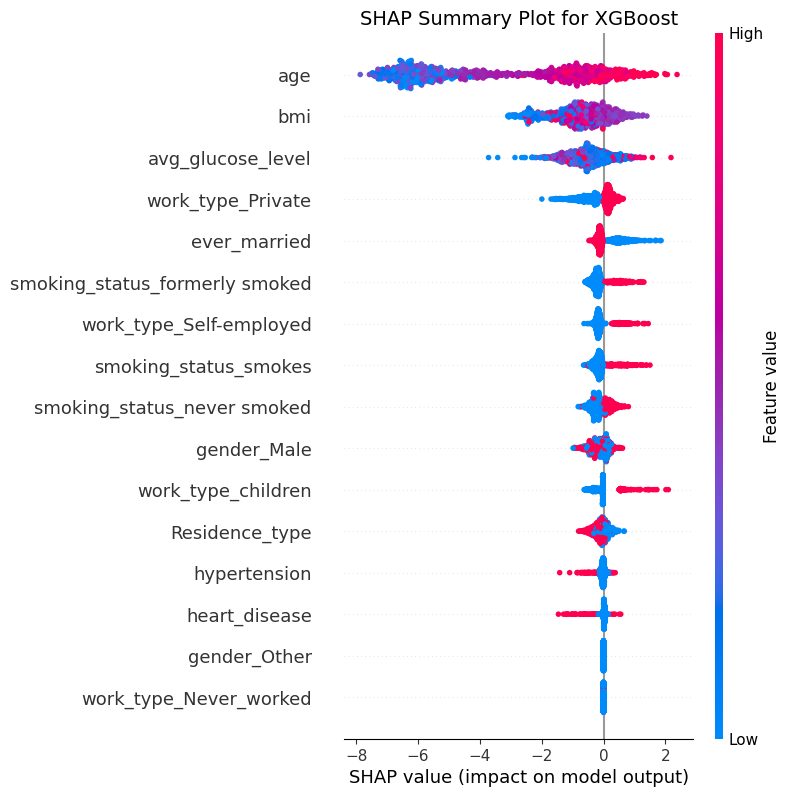


Generating SHAP Force Plots for individual predictions
This plot shows how each feature contributed to a single prediction.
Features in red push the prediction higher (towards stroke), blue pushes it lower.



Explaining a True Positive Prediction (Patient Index: 159)



Explaining a False Negative Prediction (Patient Index: 137)
This is useful for debugging why the model missed a stroke case.


In [ ]:
# STEP 8: PEAKING INSIDE THE BLACK BOX WITH SHAP (XG BOOST)

import shap

print("\nSHAP Analysis for Tuned XGBoost Model")

# We need to use the data before SMOTE for a realistic interpretation of feature importance
# on the original data distribution.
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# Visualization 1: Global Feature Importance (Summary Plot)
print("\nGenerating SHAP Summary Plot")
print("This plot shows the most important features for the model's predictions overall.")
print("Each point is a single prediction. Red points indicate a high feature value, blue is low.")
print("Features at the top are most impactful.")

shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Summary Plot for XGBoost", fontsize=14)
plt.show()


# Visualization 2: Individual Prediction Explanation (Force Plot)
print("\nGenerating SHAP Force Plots for individual predictions")
print("This plot shows how each feature contributed to a single prediction.")
print("Features in red push the prediction higher (towards stroke), blue pushes it lower.")

# Initialize javascript for force plots in Colab
shap.initjs()

# Explain a True Positive prediction (a case the model correctly identified as a stroke)
# Find a sample that was actually a stroke and was predicted as a stroke
true_positives = X_test[(y_test == 1) & (xgb_results['y_pred'] == 1)]
if not true_positives.empty:
    idx_tp = true_positives.index[0]
    print(f"\nExplaining a True Positive Prediction (Patient Index: {idx_tp})")
    display(shap.force_plot(explainer.expected_value, shap_values[idx_tp,:], X_test.loc[idx_tp,:]))
else:
    print("\nNo true positive predictions found in the test set to explain.")


# Explain a False Negative prediction (a case the model missed)
# Find a sample that was actually a stroke but was predicted as no stroke
false_negatives = X_test[(y_test == 1) & (xgb_results['y_pred'] == 0)]
if not false_negatives.empty:
    idx_fn = false_negatives.index[0]
    print(f"\nExplaining a False Negative Prediction (Patient Index: {idx_fn})")
    print("This is useful for debugging why the model missed a stroke case.")
    display(shap.force_plot(explainer.expected_value, shap_values[idx_fn,:], X_test.loc[idx_fn,:]))
else:
    print("\nNo false negative predictions found in the test set to explain.")